# Whisper-large-v2 — fine-tuning encoder

**Модель:** Whisper-large-v2, верхние 8 слоёв разморожены, mean pooling → Linear  
**Данные:** train/val/test сплит, SpecAugment на train  
**Отличия от medium:** EMBED_DIM=1280, 32 слоя энкодера, BATCH_SIZE=2, GRAD_ACCUM=4

In [6]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import time
import json
import torch

torch.backends.cudnn.benchmark = False
torch.backends.cudnn.enabled = False

from torch import nn
from torch.utils.data import Dataset, DataLoader
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score as _f1
from transformers import WhisperModel, WhisperProcessor
import matplotlib.pyplot as plt

exp_dir = Path().resolve()
sys.path.insert(0, str(exp_dir.parent.parent))

from shared import config, data_utils, train_utils
from shared.evaluate import find_optimal_threshold, evaluate
from shared.results_utils import save_result_csv

train_utils.set_seed(config.RANDOM_STATE)

DEVICE = torch.device("cuda:1" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda:1


In [7]:
(
    paths_trainval, labels_trainval, letters_trainval,
    paths_test, labels_test, letters_test,
) = data_utils.get_test_split()

idx = np.arange(len(paths_trainval))
idx_tr, idx_val = train_test_split(
    idx, test_size=0.18, stratify=labels_trainval, random_state=config.RANDOM_STATE
)
paths_train,  paths_val  = paths_trainval[idx_tr],  paths_trainval[idx_val]
labels_train, labels_val = labels_trainval[idx_tr], labels_trainval[idx_val]
letters_train, letters_val = letters_trainval[idx_tr], letters_trainval[idx_val]

print(f"Train: {len(paths_train)}, Val: {len(paths_val)}, Test: {len(paths_test)}")

Train: 1931, Val: 425, Test: 416


In [8]:
MODEL_ID = "openai/whisper-large-v2"

processor = WhisperProcessor.from_pretrained(MODEL_ID)

class WhisperDataset(Dataset):
    def __init__(self, paths, labels, letters, augment=False):
        self.paths = paths
        self.labels = labels
        self.letters = letters
        self.augment = augment

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        y, sr = data_utils.load_audio(self.paths[i], sr=16000)
        feats = processor.feature_extractor(
            y, sampling_rate=16000, return_tensors="np"
        ).input_features[0]  # (128, 3000) для large
        if self.augment:
            feats = data_utils.augment_mel_spectrogram(feats)
        return (
            torch.from_numpy(feats).float(),
            torch.from_numpy(self.letters[i]).float(),
            int(self.labels[i]),
        )

BATCH_SIZE = 2  # уменьшен по сравнению с medium (4) из-за большего размера модели
train_loader = DataLoader(
    WhisperDataset(paths_train, labels_train, letters_train, augment=True),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=0
)
val_loader = DataLoader(
    WhisperDataset(paths_val, labels_val, letters_val, augment=False),
    batch_size=BATCH_SIZE, shuffle=False
)
test_loader = DataLoader(
    WhisperDataset(paths_test, labels_test, letters_test, augment=False),
    batch_size=BATCH_SIZE, shuffle=False
)

In [9]:
N_UNFREEZE = 8   # размораживаем верхние 8 из 32 слоёв
EMBED_DIM  = 1280  # Whisper-large-v2 d_model
DROPOUT    = 0.3
N_EPOCHS   = 30

class WhisperClassifier(nn.Module):
    def __init__(self, whisper_model, n_letters=0, dropout=DROPOUT, n_unfreeze=N_UNFREEZE):
        super().__init__()
        self.encoder = whisper_model.encoder
        self.n_letters = n_letters

        for p in self.encoder.parameters():
            p.requires_grad = False

        n_layers = len(self.encoder.layers)
        for layer in self.encoder.layers[n_layers - n_unfreeze:]:
            for p in layer.parameters():
                p.requires_grad = True
        for p in self.encoder.layer_norm.parameters():
            p.requires_grad = True

        self.dropout = nn.Dropout(dropout)
        self.head = nn.Linear(EMBED_DIM + n_letters, 2)

        n_frozen = sum(not p.requires_grad for p in self.encoder.parameters())
        n_train  = sum(p.requires_grad for p in self.parameters())
        print(f"Encoder параметров замороженных: {n_frozen}")
        print(f"Всего обучаемых параметров: {n_train}")

    def forward(self, input_features, letters=None):
        hidden = self.encoder(input_features).last_hidden_state
        pooled = hidden.mean(dim=1)
        pooled = self.dropout(pooled)
        if self.n_letters > 0 and letters is not None:
            pooled = torch.cat([pooled, letters], dim=1)
        return self.head(pooled)


whisper_model = WhisperModel.from_pretrained(MODEL_ID)
n_letters = letters_train.shape[1]
model = WhisperClassifier(whisper_model, n_letters=n_letters, n_unfreeze=N_UNFREEZE).to(DEVICE)
n_params_total     = sum(p.numel() for p in model.parameters())
n_params_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nВсего параметров: {n_params_total:,}  |  Обучаемых: {n_params_trainable:,}")

Loading weights:   0%|          | 0/1259 [00:00<?, ?it/s]

Encoder параметров замороженных: 365
Всего обучаемых параметров: 124

Всего параметров: 636,787,222  |  Обучаемых: 157,414,422


In [10]:
GRAD_ACCUM = 4  # effective batch = BATCH_SIZE * GRAD_ACCUM = 8

weights = compute_class_weight("balanced", classes=np.unique(labels_train), y=labels_train)
criterion = nn.CrossEntropyLoss(
    weight=torch.tensor(weights, dtype=torch.float32).to(DEVICE),
    label_smoothing=0.1
)

encoder_params = [p for n, p in model.named_parameters()
                  if p.requires_grad and 'head' not in n]
head_params    = list(model.head.parameters())
TARGET_LR_ENCODER = 5e-6
optimizer = torch.optim.AdamW([
    {"params": encoder_params, "lr": TARGET_LR_ENCODER, "weight_decay": 1e-3},
    {"params": head_params,    "lr": 1e-4,              "weight_decay": 1e-4},
])
scheduler = train_utils.get_lr_scheduler(optimizer)
early_stopping = train_utils.EarlyStopping(patience=config.EARLY_STOPPING_PATIENCE)
best_ckpt = exp_dir / "best_ckpt.pt"
best_f1 = -1.0

N_WARMUP_EPOCHS = 2
warmup_steps = N_WARMUP_EPOCHS * len(train_loader)

def eval_loader(loader):
    model.eval()
    logits_list, true_list = [], []
    with torch.no_grad():
        for feats, letters, y in loader:
            logits = model(feats.to(DEVICE), letters.to(DEVICE))
            logits_list.append(logits.cpu().numpy())
            true_list.extend(y.tolist())
    logits = np.concatenate(logits_list)
    proba  = torch.softmax(torch.from_numpy(logits), dim=1).numpy()[:, config.CLASS_BAD]
    return proba, np.array(true_list)

train_losses, val_f1s = [], []
t0 = time.perf_counter()
global_step = 0

for epoch in range(N_EPOCHS):
    model.train()
    losses = []
    optimizer.zero_grad()
    for batch_idx, (feats, letters, y) in enumerate(train_loader):
        if global_step < warmup_steps:
            optimizer.param_groups[0]["lr"] = TARGET_LR_ENCODER * (global_step + 1) / warmup_steps

        feats, letters, y = feats.to(DEVICE), letters.to(DEVICE), y.to(DEVICE)
        loss = criterion(model(feats, letters), y) / GRAD_ACCUM
        loss.backward()
        losses.append(loss.item() * GRAD_ACCUM)

        if (batch_idx + 1) % GRAD_ACCUM == 0 or (batch_idx + 1) == len(train_loader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), config.DEFAULT_GRAD_CLIP)
            optimizer.step()
            global_step += 1
            optimizer.zero_grad()

    train_loss = np.mean(losses)
    train_losses.append(train_loss)

    val_proba, val_true = eval_loader(val_loader)
    _opt_thr = find_optimal_threshold(val_true, val_proba)
    val_f1 = _f1(val_true, (val_proba >= _opt_thr).astype(int),
                 pos_label=config.CLASS_BAD, average="binary")
    val_f1s.append(val_f1)

    if val_f1 > best_f1:
        best_f1 = val_f1
        train_utils.save_best_checkpoint(model, best_ckpt)
    if global_step > warmup_steps:
        scheduler.step(val_f1)
    print(f"Epoch {epoch+1}/{N_EPOCHS}  loss={train_loss:.4f}  "
          f"val_f1_bad={val_f1:.4f}  thr={_opt_thr:.2f}  "
          f"lr={optimizer.param_groups[0]['lr']:.2e}")
    if early_stopping.step(val_f1):
        print(f"Early stopping на эпохе {epoch+1}")
        break

train_time_sec = time.perf_counter() - t0

[W511 21:07:38.573344606 NNPACK.cpp:62] Could not initialize NNPACK! Reason: Unsupported hardware.


Epoch 1/30  loss=0.6647  val_f1_bad=0.6388  thr=0.41  lr=6.26e-07
Epoch 2/30  loss=0.5979  val_f1_bad=0.7387  thr=0.37  lr=1.25e-06
Epoch 3/30  loss=0.5312  val_f1_bad=0.7666  thr=0.29  lr=1.88e-06
Epoch 4/30  loss=0.4906  val_f1_bad=0.7889  thr=0.27  lr=2.51e-06
Epoch 5/30  loss=0.4457  val_f1_bad=0.7817  thr=0.33  lr=3.13e-06
Epoch 6/30  loss=0.4071  val_f1_bad=0.7754  thr=0.29  lr=3.76e-06
Epoch 7/30  loss=0.3644  val_f1_bad=0.7562  thr=0.19  lr=4.38e-06
Epoch 8/30  loss=0.3575  val_f1_bad=0.7708  thr=0.17  lr=5.00e-06
Epoch 9/30  loss=0.3330  val_f1_bad=0.7927  thr=0.39  lr=5.00e-06
Epoch 10/30  loss=0.3092  val_f1_bad=0.7669  thr=0.56  lr=5.00e-06
Epoch 11/30  loss=0.2888  val_f1_bad=0.7554  thr=0.17  lr=5.00e-06
Epoch 12/30  loss=0.2887  val_f1_bad=0.7536  thr=0.21  lr=5.00e-06
Epoch 13/30  loss=0.2872  val_f1_bad=0.7491  thr=0.12  lr=5.00e-06
Epoch 14/30  loss=0.2925  val_f1_bad=0.7361  thr=0.12  lr=5.00e-06
Epoch 15/30  loss=0.2793  val_f1_bad=0.7826  thr=0.74  lr=2.50e-06
Epoc

## Оценка на тесте и сохранение результатов


Обучение: 98565.4 с | best val_f1_bad=0.7927
Оптимальный порог: 0.39
              precision    recall  f1-score   support

        good       0.87      0.86      0.87       281
         bad       0.72      0.73      0.73       135

    accuracy                           0.82       416
   macro avg       0.80      0.80      0.80       416
weighted avg       0.82      0.82      0.82       416

Threshold : 0.39
Accuracy  : 0.8221
F1-macro  : 0.7979
F1-bad    : 0.7279
ROC-AUC   : 0.8699


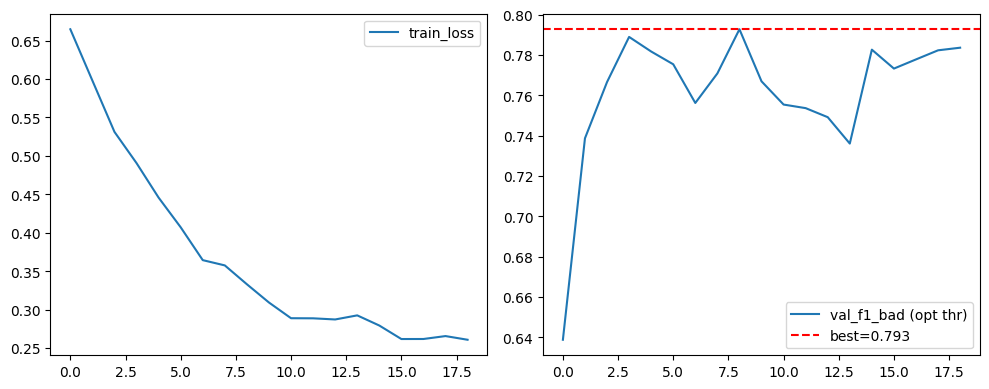

PosixPath('/home/dk/HSE_VKR_DetectingSpeechDefects/experiments/04_pretrained_finetuned/exp_whisper_large_v2_finetune/result.csv')

In [11]:
train_utils.load_best_checkpoint(model, best_ckpt, DEVICE)

print(f"\nОбучение: {train_time_sec:.1f} с | best val_f1_bad={best_f1:.4f}")

val_proba, val_true = eval_loader(val_loader)
optimal_threshold = find_optimal_threshold(val_true, val_proba)
json.dump({"threshold": float(optimal_threshold)}, open(exp_dir / "threshold.json", "w"))
print(f"Оптимальный порог: {optimal_threshold:.2f}")

test_proba, test_true = eval_loader(test_loader)
test_metrics = evaluate(test_true, test_proba, threshold=optimal_threshold, verbose=True)
pd.DataFrame({
    "path":    paths_test,
    "y_true":  test_true,
    "y_pred":  (test_proba >= optimal_threshold).astype(int),
    "y_proba": test_proba,
}).to_csv(exp_dir / "test_predictions.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(train_losses, label="train_loss"); axes[0].legend()
axes[1].plot(val_f1s, label="val_f1_bad (opt thr)")
axes[1].axhline(best_f1, color="r", linestyle="--", label=f"best={best_f1:.3f}")
axes[1].legend()
plt.tight_layout()
fig.savefig(exp_dir / "training_curves.png", dpi=120)
plt.show()

save_result_csv(
    exp_dir=exp_dir,
    experiment_id="exp_whisper_large_v2_finetune",
    experiment_name=f"Whisper-large-v2 fine-tuning (верхние {N_UNFREEZE} слоя)",
    accuracy=test_metrics["accuracy"],
    f1_macro=test_metrics["f1_macro"],
    f1_bad=test_metrics["f1_bad"],
    roc_auc=test_metrics["roc_auc"],
    precision_bad=test_metrics["precision_bad"],
    recall_bad=test_metrics["recall_bad"],
    threshold=test_metrics["threshold"],
    embed_dim=EMBED_DIM,
    embed_dim_note=f"Whisper-large-v2 encoder {EMBED_DIM}-dim, mean pooling  head=Linear({EMBED_DIM}+n_letters, 2)",
    notes=(
        f"SpecAugment + partial finetune | "
        f"n_unfreeze={N_UNFREEZE}/32 | lr_encoder=5e-6 lr_head=1e-4 | warmup=2ep | "
        f"batch={BATCH_SIZE} grad_accum={GRAD_ACCUM} | thr={optimal_threshold:.2f}"
    ),
    num_params=n_params_trainable,
    train_time_sec=train_time_sec,
)

In [ ]:
comparison = pd.DataFrame([
    {"Модель": "Whisper-large-v2 frozen + SVM",
     "Accuracy": 0.8393, "F1-macro": 0.8202, "F1-bad": 0.7616, "ROC-AUC": 0.9093},
    {"Модель": f"Whisper-large-v2 finetune ({N_UNFREEZE} слоёв) [этот эксперимент]",
     "Accuracy": test_metrics["accuracy"],
     "F1-macro": test_metrics["f1_macro"],
     "F1-bad":   test_metrics["f1_bad"],
     "ROC-AUC":  test_metrics["roc_auc"]},
])
display(comparison.set_index("Модель").round(4))